In [1]:
from sklearn.tree import DecisionTreeClassifier

### Make Sample Data

In [122]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

X, y = load_iris(return_X_y=True)
# Nunca entrenar y testear con los mismos datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

class_names=["Setosa", "Versicolor", "Virginica"]
feature_names=["Sepal Length", "Sepal Width", "Petal Length", "Petal Width"]

### Create Decision Tree Sin Restricciones

In [123]:
decisionTree = DecisionTreeClassifier()
decisionTree.fit(X_train, y_train)

DecisionTreeClassifier()

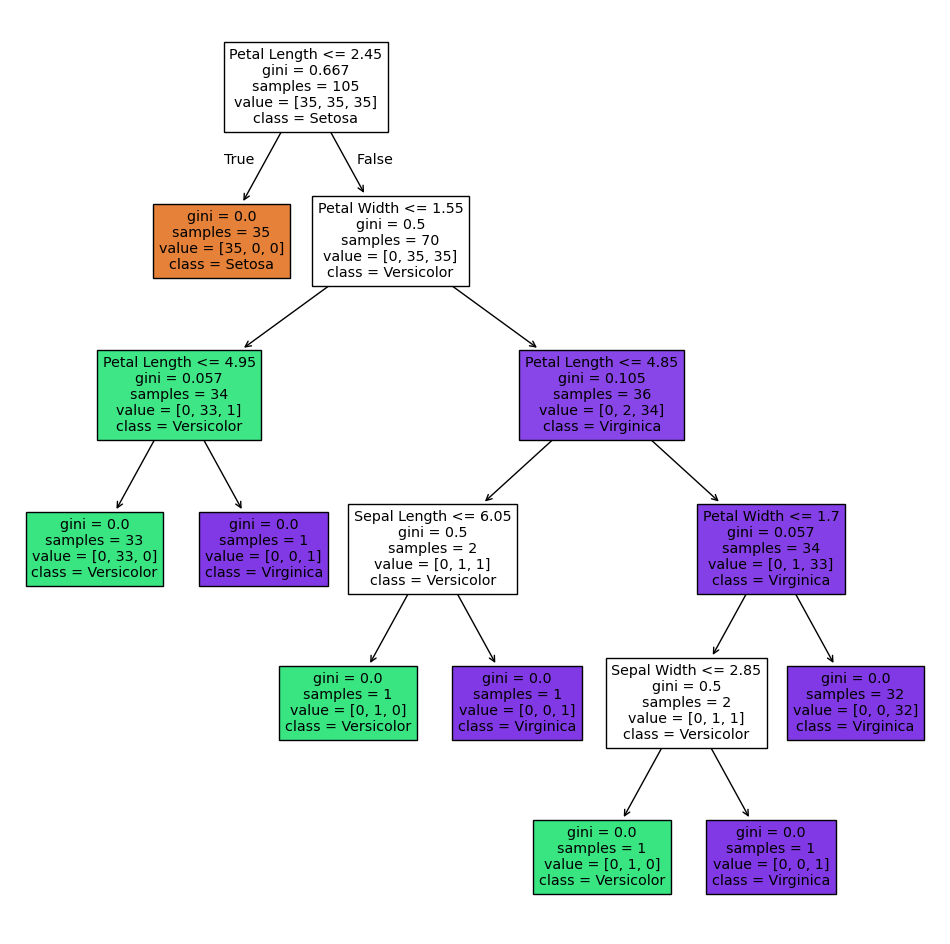

In [124]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(12, 12))
plot_tree(
    decisionTree,
    feature_names=feature_names,
    class_names=class_names,
    filled=True
)
plt.show()


### Create Decision Tree Con Restricciones

In [125]:
decisionTreeModified = DecisionTreeClassifier(criterion="entropy", min_samples_split=4, min_samples_leaf=2, max_depth=4)
decisionTreeModified.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, min_samples_leaf=2,
                       min_samples_split=4)

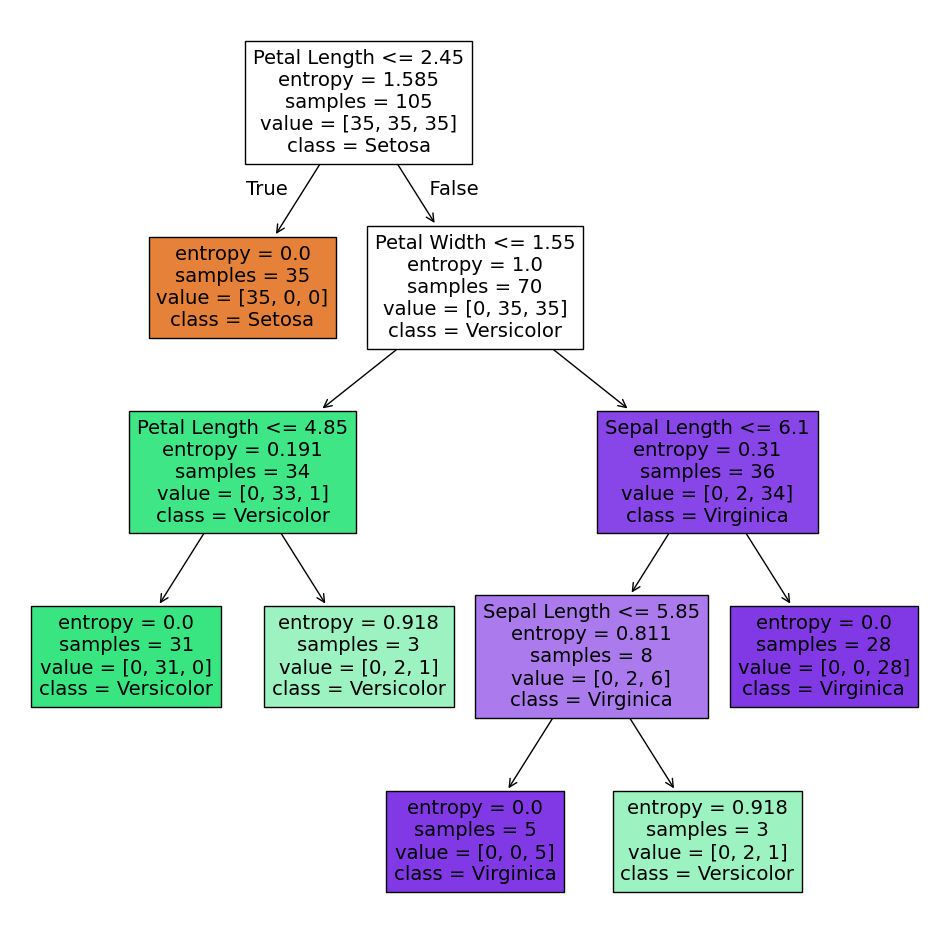

In [126]:
plt.figure(figsize=(12, 12))
plot_tree(
    decisionTreeModified,
    feature_names=feature_names,
    class_names=class_names,
    filled=True
)
plt.show()


### Test Predictions of both Trees

In [127]:
print("No Limit Decision Tree: ", class_names[decisionTree.predict([[5.1, 10, 1.4, 12]])[0]])
print("Limited and Modified Decision Tree: ", class_names[decisionTreeModified.predict([[5.1, 10, 1.4, 0.4]])[0]])

No Limit Decision Tree:  Setosa
Limited and Modified Decision Tree:  Setosa


### Test Cross Validation

In [137]:
from sklearn.model_selection import cross_val_score
print("Not Modified Cross Validation Score: ", cross_val_score(decisionTree, X_test, y_test, cv=5).mean())
print("Modified Cross Validation Score: ", cross_val_score(decisionTreeModified, X_test, y_test, cv=5).mean())

Not Modified Cross Validation Score:  0.888888888888889
Modified Cross Validation Score:  0.888888888888889
